In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Charger dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# Colonnes choisies
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# Encodage
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Séparer X / y
X = df.drop("Status", axis=1)
y = df["Status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion="entropy", max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred, average='weighted'))
print("Recall :", recall_score(y_test, y_pred, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.5026774917947832
Precision : 0.6265995774836437
Recall : 0.5026774917947832
F1-score : 0.38899725852736816


C:\Users\aziza\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


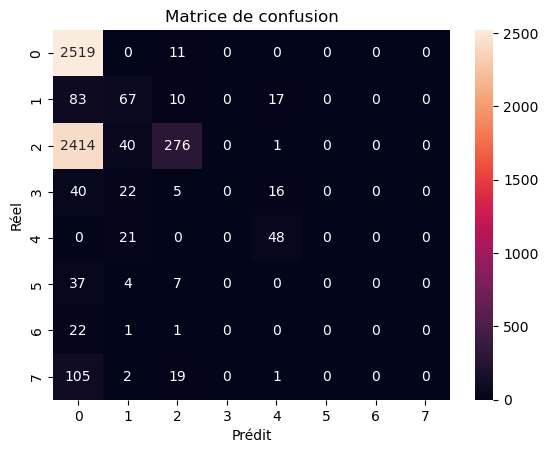

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Scores :", scores)
print("Moyenne :", scores.mean())

Scores : [0.47659354 0.50595958 0.51079634 0.51071182 0.50207326]
Moyenne : 0.5012269056856993


In [8]:
print("Score Train :", model.score(X_train, y_train))
print("Score Test :", model.score(X_test, y_test))

Score Train : 0.5050963116524143
Score Test : 0.5026774917947832
